# 반도체 공정 스케줄링 시뮬레이션 결과 비교

## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import product

plt.rcParams['font.family'] = 'Noto Sans KR'

load_dotenv()

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")

BASE_DATA_PATH: data
PM_HAZARD_THRESHOLD: 0.2
PM_ACTIVE: True
DOWN_ACTIVE: True

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

Jobs: 10 개 / Operations: 35 개 / Machines: 8 개

## 룰 비교 함수 정의

In [4]:
def run_simulation(machine_rule, job_rule, pm_rule):
    env = simpy.Environment()
    logger = EventLogger(env)

    os.environ['MACHINE_RULE'] = machine_rule
    os.environ['JOB_RULE'] = job_rule
    os.environ['PM_RULE'] = pm_rule
    scheduler = Scheduler(
        env=env,
        data=data,
        event_logger=logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD)
    )
    env.run(until=scheduler.job_chk_process)
    return logger.logs

## 룰별 N회 시뮬레이션 평균 비교

In [5]:
N_RUNS = 1000
MACHINE_RULES = [
    'SPTSSU'
]
JOB_RULES = [
    'random',
    'FIFO',
    'SPT',
    'LPT',
    'MIN_QTIME',
    'SPTSSU'
]
PM_RULES = [
    'THRESHOLD'
]

metrics = []
seed = time.time()
for (machine_rule, job_rule, pm_rule, idx) in product(MACHINE_RULES, JOB_RULES, PM_RULES, range(N_RUNS)):
    random.seed(hash((seed, idx)))
    log = pd.DataFrame(run_simulation(machine_rule, job_rule, pm_rule))
    job_log = log[log['resource'] == 'job']
    machine_log = log[log['resource'] == 'machine']

    makespan = job_log.groupby('id')['finish'].max().max()
    flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
    job_type_map = data['jobs'].set_index('job_id')['job_type']
    flowtime = flowtime.to_frame(name='flowtime').join(job_type_map, on='id')
    flowtime = flowtime.groupby('job_type')['flowtime'].mean()

    completed = job_log.groupby('id')['finish'].max()
    job_duetime_map = data['jobs'].set_index('job_id')['due_date']
    tardiness = completed.to_frame(name='completed').join(job_duetime_map, on='id')
    tardiness = (tardiness['completed'] - tardiness['due_date']).apply(lambda x: max(x, 0)).to_frame(name='tardiness')
    tardiness = tardiness.join(job_type_map, on='id')
    tardiness = tardiness.groupby('job_type')['tardiness'].mean()

    qtime_violations = job_log[job_log['event'] == 'qtime_over']
    qtime_violations = sum(qtime_violations['finish'] - qtime_violations['start'])

    n_pm = len(machine_log[machine_log['event'] == 'PM'])
    n_repairs = len(machine_log[machine_log['event'] == 'repairing'])

    utilization = machine_log[machine_log['event'] == 'working'].groupby('id').apply(lambda x: (x['finish'] - x['start']).sum() / makespan)
    machine_group_map = data['machines'].set_index('machine_id')['machine_group']
    utilization = utilization.to_frame(name='utilization').join(machine_group_map, on='id')
    utilization = utilization.groupby('machine_group')['utilization'].mean()

    metrics.append({
        'machine_rule': machine_rule,
        'job_rule': job_rule,
        'pm_rule': pm_rule,
        'try': idx + 1,
        'makespan': makespan,
        'flowtime': flowtime,
        'tardiness': tardiness,
        'qtime_violations': qtime_violations,
        'n_pm': n_pm,
        'n_repairs': n_repairs,
        'utilization': utilization
    })
metrics_df = pd.DataFrame(metrics)

## Makespan

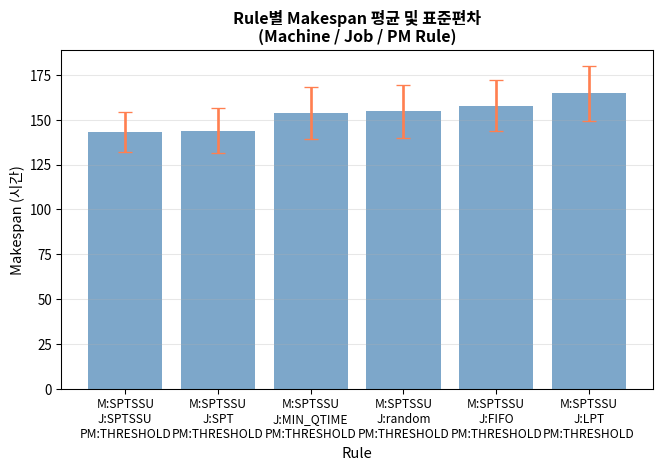

In [6]:
fig, ax = plt.subplots()

# Rule별 Makespan 평균 및 표준편차 (machine_rule, job_rule, pm_rule별로 그룹화)
makespan_stats = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule']).agg({
    'makespan': ['mean', 'std']
}).droplevel(0, axis=1).sort_values('mean')

# Barplot with error bars
x_pos = range(len(makespan_stats))
ax.bar(x_pos, makespan_stats['mean'], yerr=makespan_stats['std'],
       capsize=5, alpha=0.7, color='steelblue', error_kw={'linewidth': 2, 'ecolor': 'coral'})

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('Makespan (시간)', fontsize=11)
ax.set_title('Rule별 Makespan 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)

# 라벨 생성: Machine Rule / Job Rule / PM Rule 형식
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in makespan_stats.index]
ax.set_xticklabels(rule_labels, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Flowtime & Tardiness

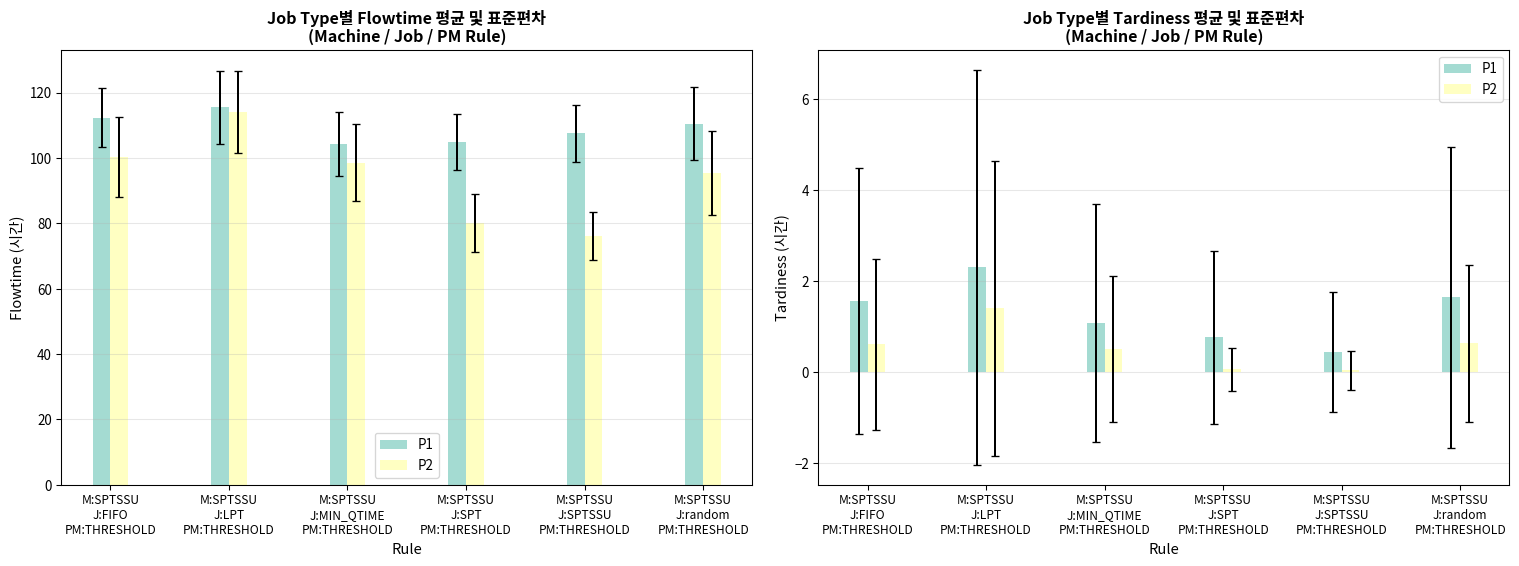

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flowtime by Job Type
flowtime_data = []
for idx, row in metrics_df.iterrows():
    for job_type, flowtime_val in row['flowtime'].items():
        flowtime_data.append({
            'machine_rule': row['machine_rule'],
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'job_type': job_type,
            'flowtime': flowtime_val
        })

flowtime_df = pd.DataFrame(flowtime_data)
flowtime_mean = flowtime_df.pivot_table(values='flowtime', index=['machine_rule', 'job_rule', 'pm_rule'], columns='job_type', aggfunc='mean')
flowtime_std = flowtime_df.pivot_table(values='flowtime', index=['machine_rule', 'job_rule', 'pm_rule'], columns='job_type', aggfunc='std')

x_pos = range(len(flowtime_mean))
job_types = flowtime_mean.columns
colors = plt.cm.Set3(range(len(job_types)))

for i, job_type in enumerate(job_types):
    axes[0].bar([x + i * 0.15 for x in x_pos], flowtime_mean[job_type], yerr=flowtime_std[job_type],
                width=0.15, label=job_type, color=colors[i], alpha=0.8,
                error_kw={'linewidth': 1.5, 'ecolor': 'black', 'capsize': 3})

axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel('Flowtime (시간)', fontsize=11)
axes[0].set_title('Job Type별 Flowtime 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[0].set_xticks([x + 0.15 * (len(job_types) - 1) / 2 for x in x_pos])
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in flowtime_mean.index]
axes[0].set_xticklabels(rule_labels, fontsize=9)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Tardiness by Job Type
tardiness_data = []
for idx, row in metrics_df.iterrows():
    for job_type, tardiness_val in row['tardiness'].items():
        tardiness_data.append({
            'machine_rule': row['machine_rule'],
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'job_type': job_type,
            'tardiness': tardiness_val
        })

tardiness_df = pd.DataFrame(tardiness_data)
tardiness_mean = tardiness_df.pivot_table(values='tardiness', index=['machine_rule', 'job_rule', 'pm_rule'], columns='job_type', aggfunc='mean')
tardiness_std = tardiness_df.pivot_table(values='tardiness', index=['machine_rule', 'job_rule', 'pm_rule'], columns='job_type', aggfunc='std')

x_pos = range(len(tardiness_mean))
job_types = tardiness_mean.columns
colors = plt.cm.Set3(range(len(job_types)))

for i, job_type in enumerate(job_types):
    axes[1].bar([x + i * 0.15 for x in x_pos], tardiness_mean[job_type], yerr=tardiness_std[job_type],
                width=0.15, label=job_type, color=colors[i], alpha=0.8,
                error_kw={'linewidth': 1.5, 'ecolor': 'black', 'capsize': 3})

axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel('Tardiness (시간)', fontsize=11)
axes[1].set_title('Job Type별 Tardiness 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[1].set_xticks([x + 0.15 * (len(job_types) - 1) / 2 for x in x_pos])
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in tardiness_mean.index]
axes[1].set_xticklabels(rule_labels, fontsize=9)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Qtime Violation

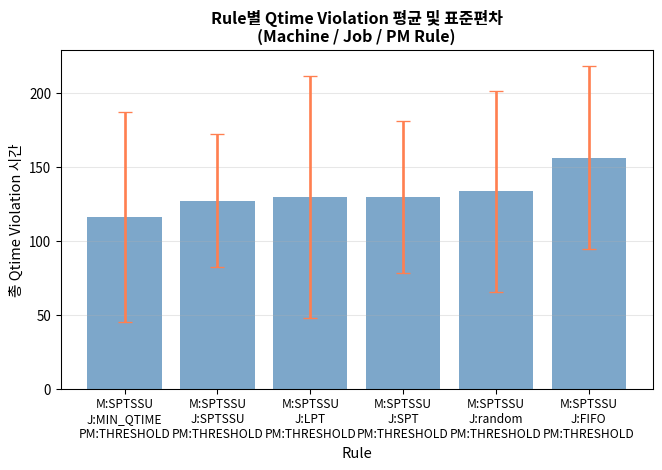

In [8]:
fig, ax = plt.subplots()

# Rule별 Qtime Violation 평균 및 표준편차 (machine_rule, job_rule, pm_rule별로 그룹화)
qtime_stats = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule']).agg({
    'qtime_violations': ['mean', 'std']
}).droplevel(0, axis=1).sort_values('mean')

# Barplot with error bars
x_pos = range(len(qtime_stats))
ax.bar(x_pos, qtime_stats['mean'], yerr=qtime_stats['std'],
       capsize=5, alpha=0.7, color='steelblue', error_kw={'linewidth': 2, 'ecolor': 'coral'})

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('총 Qtime Violation 시간', fontsize=11)
ax.set_title('Rule별 Qtime Violation 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)

# 라벨 생성: Machine Rule / Job Rule / PM Rule 형식
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in qtime_stats.index]
ax.set_xticklabels(rule_labels, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## PM & Repair

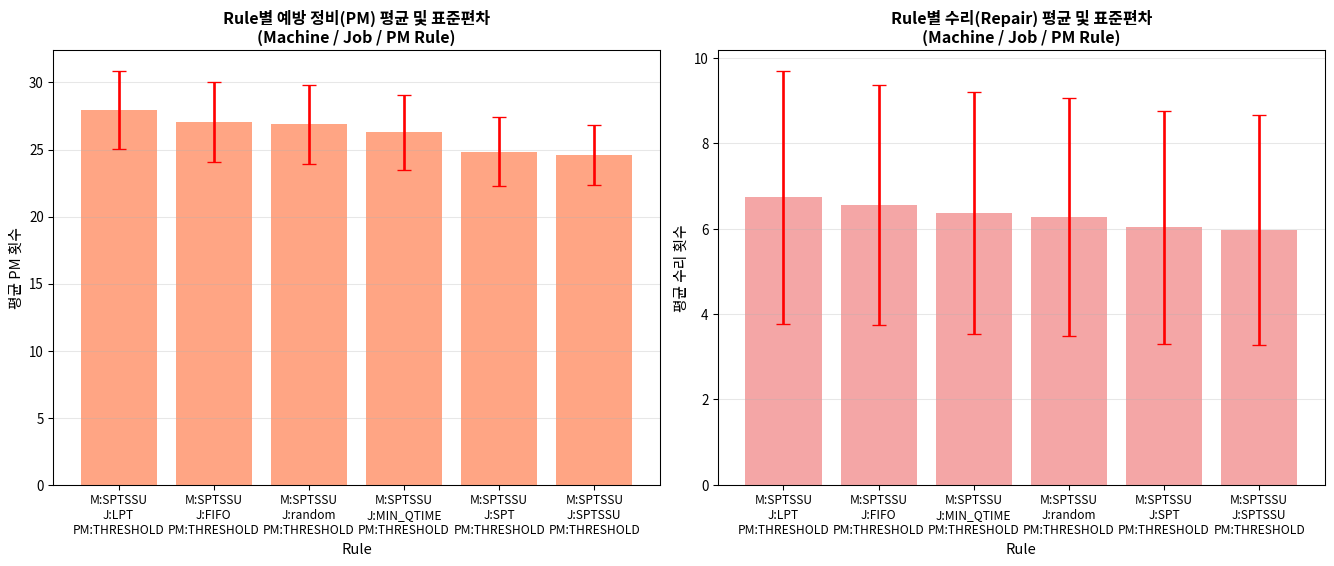

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PM 비교 (machine_rule, job_rule, pm_rule별로 그룹화)
pm_stats = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule']).agg({
    'n_pm': ['mean', 'std']
}).droplevel(0, axis=1).sort_values('mean', ascending=False)

x_pos = range(len(pm_stats))
axes[0].bar(x_pos, pm_stats['mean'], yerr=pm_stats['std'],
            capsize=5, alpha=0.7, color='coral', error_kw={'linewidth': 2, 'ecolor': 'red'})
axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel('평균 PM 횟수', fontsize=11)
axes[0].set_title('Rule별 예방 정비(PM) 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
rule_labels_pm = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in pm_stats.index]
axes[0].set_xticklabels(rule_labels_pm, fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Repair 비교 (machine_rule, job_rule, pm_rule별로 그룹화)
repair_stats = metrics_df.groupby(['machine_rule', 'job_rule', 'pm_rule']).agg({
    'n_repairs': ['mean', 'std']
}).droplevel(0, axis=1).sort_values('mean', ascending=False)

x_pos = range(len(repair_stats))
axes[1].bar(x_pos, repair_stats['mean'], yerr=repair_stats['std'],
            capsize=5, alpha=0.7, color='lightcoral', error_kw={'linewidth': 2, 'ecolor': 'red'})
axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel('평균 수리 횟수', fontsize=11)
axes[1].set_title('Rule별 수리(Repair) 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
rule_labels_repair = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in repair_stats.index]
axes[1].set_xticklabels(rule_labels_repair, fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Utilization

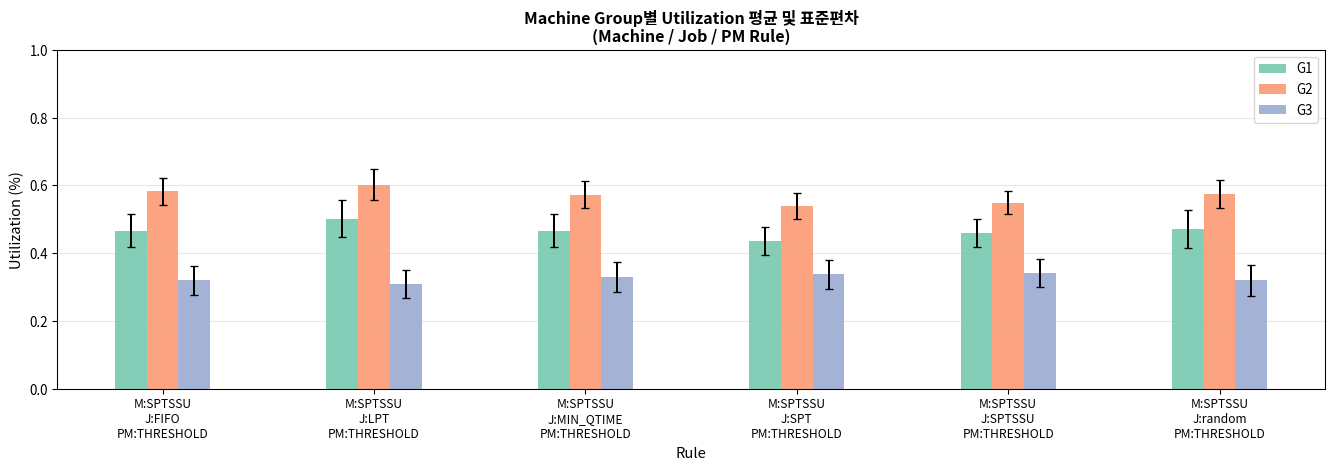

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Utilization by Machine Group
utilization_data = []
for idx, row in metrics_df.iterrows():
    for machine_group, util_val in row['utilization'].items():
        utilization_data.append({
            'machine_rule': row['machine_rule'],
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'machine_group': machine_group,
            'utilization': util_val
        })

utilization_df = pd.DataFrame(utilization_data)
utilization_mean = utilization_df.pivot_table(values='utilization', index=['machine_rule', 'job_rule', 'pm_rule'], columns='machine_group', aggfunc='mean')
utilization_std = utilization_df.pivot_table(values='utilization', index=['machine_rule', 'job_rule', 'pm_rule'], columns='machine_group', aggfunc='std')

x_pos = range(len(utilization_mean))
machine_groups = utilization_mean.columns
colors = plt.cm.Set2(range(len(machine_groups)))

for i, machine_group in enumerate(machine_groups):
    axes.bar([x + i * 0.15 for x in x_pos], utilization_mean[machine_group], yerr=utilization_std[machine_group],
             width=0.15, label=machine_group, color=colors[i], alpha=0.8,
             error_kw={'linewidth': 1.5, 'ecolor': 'black', 'capsize': 3})

axes.set_xlabel('Rule', fontsize=11)
axes.set_ylabel('Utilization (%)', fontsize=11)
axes.set_title('Machine Group별 Utilization 평균 및 표준편차\n(Machine / Job / PM Rule)', fontsize=12, fontweight='bold')
axes.set_xticks([x + 0.15 * (len(machine_groups) - 1) / 2 for x in x_pos])
rule_labels = [f"M:{idx[0]}\nJ:{idx[1]}\nPM:{idx[2]}" for idx in utilization_mean.index]
axes.set_xticklabels(rule_labels, fontsize=9)
axes.legend(fontsize=10)
axes.grid(True, alpha=0.3, axis='y')
axes.set_ylim([0, 1])

plt.tight_layout()
plt.show()